In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp

In [2]:
def here():
    try:
        return Path(__file__).resolve().parent   # script file’s folder
    except NameError:
        return Path.cwd().resolve()              # notebook/REPL

processed_data = (here().parents[1] / "2024_Nov" / "Processed_data").resolve()
anndata = sc.read_h5ad(f"{processed_data}/Limb-Muscle_Processed_Data.h5ad")

In [3]:
subset_object = anndata[anndata.obs["cell_ontology_class"] == "skeletal muscle satellite cell"].copy()

In [4]:
colors = ["#2ca02c", "#ff7f0e", "#1f77b4", "#e8a2c4"]

/Users/chanyue/anaconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/chanyue/anaconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


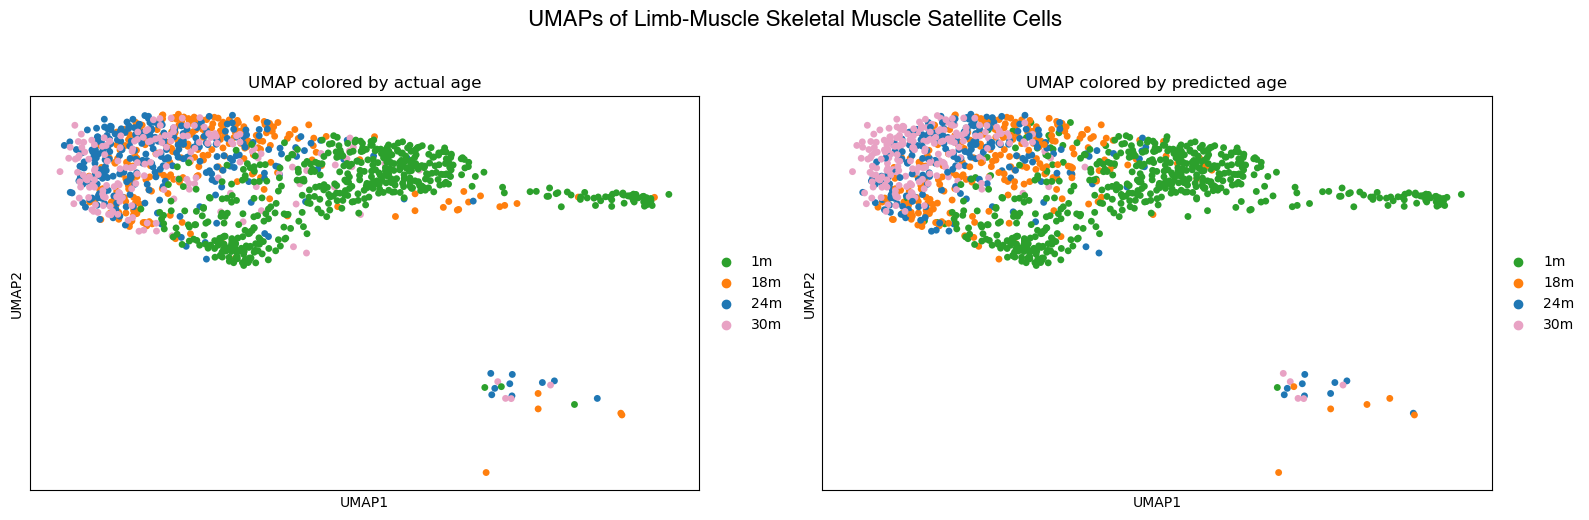

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
sc.pl.umap(subset_object, color="age", ax=axs[0], show=False, palette=colors, title='UMAP colored by actual age')
sc.pl.umap(subset_object, color="pred_age", ax=axs[1], show=False, palette=colors, title='UMAP colored by predicted age')
plt.suptitle("UMAPs of Limb-Muscle Skeletal Muscle Satellite Cells", fontname="helvetica", fontsize=16, y=1.03)
plt.tight_layout()
fig.savefig(f"./Heterogeneity/Limb-Muscle_skeletal muscle satellite cell_model.png", bbox_inches='tight', dpi = 600)
plt.show()

In [6]:
X_scaled = subset_object.X
std = subset_object.var["std"].to_numpy()

if sp.issparse(X_scaled):
    X_log1p = (X_scaled @ sp.diags(std)).astype(np.float32)
else:
    X_log1p = (np.asarray(X_scaled) * std).astype(np.float32)

subset_object.layers["log1p_unscaled"] = X_log1p

In [7]:
sc.tl.rank_genes_groups(
    subset_object,
    groupby="age",
    method="wilcoxon",
    use_raw=False,
    layer="log1p_unscaled"   # <- log-normalized values (unscaled)
)
DEG_df = sc.get.rank_genes_groups_df(subset_object, group=None)
DEG_df = DEG_df[DEG_df["pvals_adj"] < 0.05]

In [8]:
# Collagen VI alpha-1 
gene = "Col6a1"

In [9]:
DEG_df[DEG_df["names"] == gene]

,group,names,scores,logfoldchanges,pvals,pvals_adj
5,1m,Col6a1,12.498479,1.912774,7.609325e-36,1.073175e-33
32871,18m,Col6a1,-4.458338,-0.943547,8.259761e-06,3.744349e-04
49493,24m,Col6a1,-6.844525,-1.446259,7.672986e-12,1.179390e-09
65962,30m,Col6a1,-4.197894,-1.021319,2.694093e-05,3.488283e-03


In [10]:
gene_expr = subset_object[:, gene].X
if hasattr(gene_expr, "toarray"):  # convert sparse to dense
    gene_expr = gene_expr.toarray().flatten()
else:
    gene_expr = gene_expr.flatten()

df = pd.DataFrame({
    "Gene Expression": gene_expr,
    "age": subset_object.obs["age"].values,
    "pred_age": subset_object.obs["pred_age"].values
})

In [11]:
palette = plt.cm.Dark2.colors
palette_1 = plt.cm.Set2.colors
color = [palette[0], palette_1[0]]  # [line color, box fill]

In [12]:
def box_with_capline(ax, df, cat_col, val_col, title, val_label="Expression"):
    d = df.copy()
    d[cat_col] = d[cat_col].astype(str)
    d["_age_num"] = pd.to_numeric(
        d[cat_col].str.extract(r"(\d+\.?\d*)")[0], errors="coerce"
    )
    d = d.sort_values("_age_num", ascending=True).drop(columns="_age_num")
    cats = d[cat_col].to_numpy()
    order = list(pd.Series(cats).drop_duplicates())

    x = np.arange(len(order))

    sns.boxplot(
        data=d,
        x=cat_col, y=val_col, order=order, ax=ax,
        color=color[1],  # same as your bar fill
        width=0.6,
        showfliers=False,
        boxprops=dict(alpha=0.6),
        medianprops=dict(linewidth=1.2, color="black"),
        whiskerprops=dict(alpha=1),
        capprops=dict(alpha=0.8)
    )

    means = d.groupby(cat_col, sort=False)[val_col].mean().reindex(order).to_numpy()

    ymin, ymax = ax.get_ylim()
    cap_offset = (ymax - ymin) * 0.03
    y_means_cap = means + cap_offset

    ax.plot(x, y_means_cap, color=color[0], linewidth=2.0, alpha=0.5)
    scatter = ax.scatter(x, y_means_cap, color=color[0], s=20, zorder=3, label="Average Expression")

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_title(title, pad=30, fontname="helvetica", weight="bold")
    ax.set_ylabel(val_label)
    ax.yaxis.grid(True, linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(handles=[scatter], loc="upper left", frameon=True, fontsize=8, bbox_to_anchor=(1.05, 0.5))

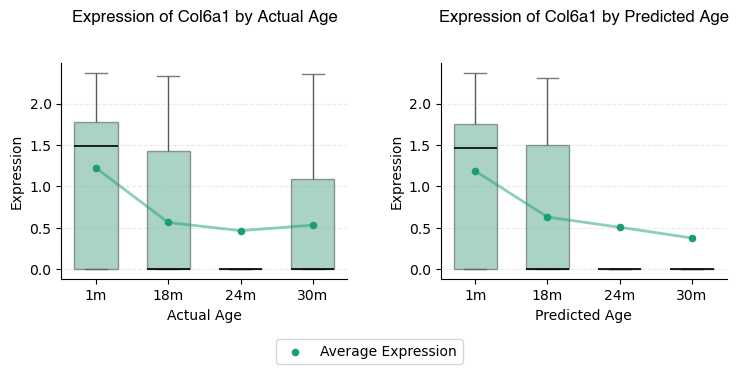

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

box_with_capline(
    axes[0], df.rename(columns={"age": "Actual Age"}),
    "Actual Age", "Gene Expression",
    title=f"Expression of {gene} by Actual Age"
)

box_with_capline(
    axes[1], df.rename(columns={"pred_age": "Predicted Age"}),
    "Predicted Age", "Gene Expression",
    title=f"Expression of {gene} by Predicted Age"
)

# Remove per-axis legends
for ax in axes:
    ax.get_legend().remove()

# Add shared legend for the scatter dots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=1, frameon=True)

plt.tight_layout(pad=3.0, rect=[0, 0.01, 1, 1])  # leave space for legend

fig.savefig(f"./Heterogeneity/Limb-Muscle_skeletal muscle satellite cell {gene}_boxplots.png",
            bbox_inches='tight', dpi=600)
plt.show()

In [14]:
gene = "Sparc"

In [15]:
DEG_df[DEG_df["names"] == gene]

,group,names,scores,logfoldchanges,pvals,pvals_adj
2,1m,Sparc,18.598753,1.334642,3.288641e-77,1.154593e-74
49502,24m,Sparc,-13.300153,-1.345035,2.309956e-40,1.905829e-36
66002,30m,Sparc,-9.624218,-1.021702,6.318594e-22,2.606578e-18


In [16]:
gene_expr = subset_object[:, gene].X
if hasattr(gene_expr, "toarray"):  # convert sparse to dense
    gene_expr = gene_expr.toarray().flatten()
else:
    gene_expr = gene_expr.flatten()

df = pd.DataFrame({
    "Gene Expression": gene_expr,
    "age": subset_object.obs["age"].values,
    "pred_age": subset_object.obs["pred_age"].values
})

In [17]:
gene_expr

array([2.1500418, 1.9654989, 1.9898965, ..., 2.4323702, 2.612868 ,
       2.0425236], dtype=float32)

In [18]:
palette = plt.cm.Dark2.colors
palette_1 = plt.cm.Set2.colors
color = [palette[1], palette_1[1]]

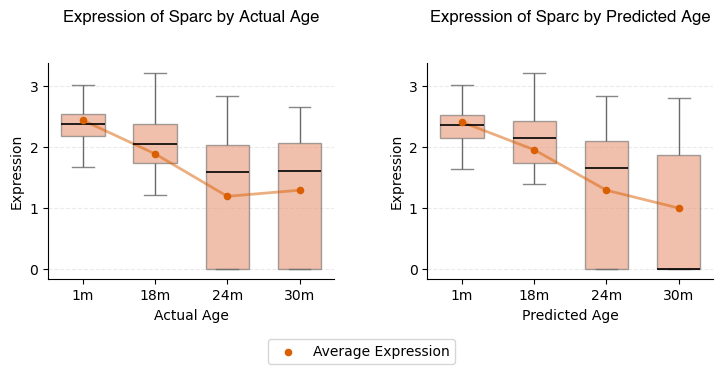

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

box_with_capline(
    axes[0], df.rename(columns={"age": "Actual Age"}),
    "Actual Age", "Gene Expression",
    title=f"Expression of {gene} by Actual Age"
)

box_with_capline(
    axes[1], df.rename(columns={"pred_age": "Predicted Age"}),
    "Predicted Age", "Gene Expression",
    title=f"Expression of {gene} by Predicted Age"
)

# Remove per-axis legends
for ax in axes:
    ax.get_legend().remove()

# Add shared legend for the scatter dots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=1, frameon=True)

plt.tight_layout(pad=3.0, rect=[0, 0.01, 1, 1])  # leave space for legend

fig.savefig(f"./Heterogeneity/Limb-Muscle_skeletal muscle satellite cell {gene}_boxplots.png",
            bbox_inches='tight', dpi=600)
plt.show()